# Portfolio Project: E-Commerce Retail Transaction Analysis

## Phase 1: Project Initialization & Data Auditing

### 1.1 Objective & Dataset
This project focuses on auditing, cleaning, and preprocessing a high-volume global retail transaction dataset. The goal is to transform raw, anomaly-ridden sales records into an analytics-ready asset suitable for core business intelligence and exploratory data analysis.
* **Data Source:** Automated pipeline streaming transactional data.
* **Key Analytical Goals:** Track high-level performance KPIs, isolate geographic revenue distribution, and profile monthly sales trends to identify retail seasonality.

### 1.2 Data Loading & Initial Inspection
To begin the audit, we establish our environment and run our primary diagnostic checks (`head()`, `info()`, and `describe()`) to evaluate structural integrity, audit data types, and locate missing data profiles.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
# Point to your local zip file name
local_zip_filename = "OnlineRetail.csv.zip" 
data_url = "https://github.com/johnkenke/AnalystLab-Data-Analysis-Portfolio/raw/main/Week_02_Online_Retail_Analysis/OnlineRetail.csv.zip" # Keep this link for others/future use

if os.path.exists(local_zip_filename):
    print("🚀 Instantly reading and unzipping data from local system archive...")
   # Add the encoding parameter to handle special characters like the £ symbol
    df = pd.read_csv(local_zip_filename, compression='zip', encoding='ISO-8859-1')
else:
    print("🌐 File not found locally. Streaming from remote repository...")
    df = pd.read_csv(data_url)
    # Optional: saves it as a zip if you want to mirror the setup
    df.to_csv(local_zip_filename, index=False, compression='zip')

print(f"Data successfully loaded! Total rows: {df.shape[0]}")

🚀 Instantly reading and unzipping data from local system archive...
Data successfully loaded! Total rows: 541909


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Get summary information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# checking to see which columns have missing values and how many
# df.isnull().sum()
# Check total and percentage of missing values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a clean summary table
missing_summary = pd.DataFrame({'Total Missing': missing_data, 'Percentage (%)': missing_percent})
print(missing_summary[missing_summary['Total Missing'] > 0])

             Total Missing  Percentage (%)
Description           1454        0.268311
CustomerID          135080       24.926694


In [6]:
# Count the number of duplicate rows across the entire dataset
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Calculate percentage of data that is duplicated
duplicate_percent = (duplicate_count / len(df)) * 100
print(f"Percentage of duplicate rows: {duplicate_percent:.2f}%")

Number of duplicate rows: 5268
Percentage of duplicate rows: 0.97%


In [7]:
# Get a quick descriptive statistical summary of numeric columns
print(df[['Quantity', 'UnitPrice']].describe())

            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


In [8]:
# View rows with negative unit prices to see what they are
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [9]:
# Check if negative quantities match up with invoices starting with 'C'
returns_check = df[df['Quantity'] < 0]
print(f"Total rows with negative quantities: {len(returns_check)}")
print(f"Rows where InvoiceNo starts with 'C': {returns_check['InvoiceNo'].astype(str).str.startswith('C').sum()}")

Total rows with negative quantities: 10624
Rows where InvoiceNo starts with 'C': 9288


## Phase 2: Core Preprocessing & Data Cleaning Pipeline

### 2.1 Missing Value Strategy
Initial auditing of the dataset revealed a substantial profile of missing values within the `CustomerID` column. While these blank entries typically represent guest checkouts or unregistered transactions, leaving them unaddressed can cause critical structural breaks during downstream data grouping and model building. 

To maintain structural consistency and preserve a strictly numeric data schema, missing records were backfilled using a standard numeric placeholder (`0`) rather than mixed text strings (such as "Guest"). This strategic decision ensures the column remains uniform, preventing type errors during numerical analysis.

### 2.2 Data Type Optimization
Several columns containing generic or inefficient baseline data types were explicitly recast. This process optimizes memory allocation within the Python environment and enables accurate mathematical and chronological operations:

* **`CustomerID`:** Converted from a floating-point decimal (e.g., `17850.0`) to a clean, non-decimal integer (`int`) format to establish clean, standard record indexing.
* **`InvoiceDate`:** Transformed from a generic text string object into a true Python `datetime` format. This conversion is crucial for unlocking Pandas time-series properties, allowing us to perform monthly chronological grouping and trend parsing.

### 2.3 Anomaly Detection & Operational Filtering
Running descriptive statistical summary checks via `df.describe()` exposed severe statistical anomalies. Most notably, the minimum values for both `Quantity` and `UnitPrice` dropped heavily below zero, revealing systemic data noise that would heavily skew baseline revenue calculations.

Further diagnostic deep-dives isolated two distinct sources of these negative numbers:
1. **Negative Unit Prices:** Tied directly to non-transactional accounting adjustments (e.g., "Adjust bad debt").
2. **Negative Quantities:** Dominated by official customer order cancellations and product returns, flagged by an invoice prefix of "C".

Because the primary objective of this portfolio analysis is to map active consumer purchase behavior and successful revenue generation, a definitive operational filter was applied. The dataset was pruned to retain exclusively rows where `Quantity > 0` and `UnitPrice > 0`. This eliminated all cancellations, debt corrections, and zero-price freebies, resulting in a refined, highly accurate transactional dataset ready for exploratory analysis.

In [10]:
# Drop duplicates, keeping the first occurrence, and modify the dataframe inline
df = df.drop_duplicates(keep='first')

# Verify the new shape of your dataset
print(f"New dataset shape: {df.shape}")
print(f"Total rows remaining: {len(df):,}")

New dataset shape: (536641, 8)
Total rows remaining: 536,641


In [11]:
# 1. Drop rows where Description is missing
df = df.dropna(subset=['Description'])

# 2. Fill missing CustomerIDs with a placeholder value ("0")
df['CustomerID'] = df['CustomerID'].fillna("0")

# 3. Verify that there are no more missing values in the dataset
print("Missing values per column after cleaning:")
print(df.isnull().sum())

Missing values per column after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [12]:
# Convert CustomerID from float (e.g., 17850.0) to integer (e.g., 17850)
df['CustomerID'] = df['CustomerID'].astype(int)
# Convert InvoiceDate from an object (string) to a true datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Convert Country from an object (string) to a category type
df['Country'] = df['Country'].astype('category')

In [13]:
# Keep only valid transactions (positive quantities and positive prices)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Verify that all negative values are gone
print("--- Final Cleaned Numeric Summary ---")
print(df[['Quantity', 'UnitPrice']].describe())
print(f"\nFinal row count for your analysis: {len(df):,}")

--- Final Cleaned Numeric Summary ---
            Quantity      UnitPrice
count  524878.000000  524878.000000
mean       10.616600       3.922573
std       156.280031      36.093028
min         1.000000       0.001000
25%         1.000000       1.250000
50%         4.000000       2.080000
75%        11.000000       4.130000
max     80995.000000   13541.330000

Final row count for your analysis: 524,878


## Phase 3: Exploratory Data Analysis (EDA) & Insights

### 3.1 Feature Engineering & Macro KPI Profiling
To transition from data preprocessing to business intelligence, we engineer a critical transactional metric: `TotalRevenue`. This is calculated by multiplying the validated `Quantity` and `UnitPrice` columns ($TotalRevenue = Quantity \times UnitPrice$). 

Using this calculated feature, we extract macro-level Key Performance Indicators (KPIs) to establish a financial and operational baseline for the entire dataset, mapping out overall sales performance, unique order volume, and average order value (AOV).

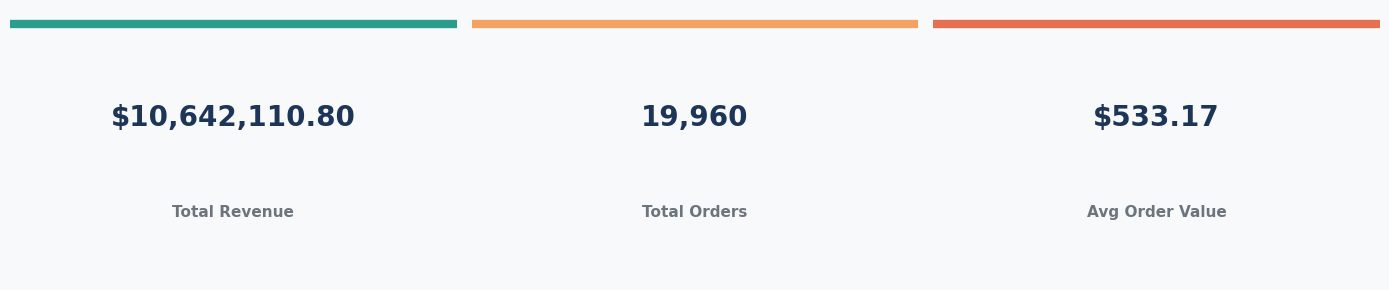

In [14]:
# 1. Ensure TotalRevenue exists and calculate metrics
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
total_sales_revenue = df['TotalRevenue'].sum()
total_orders = df['InvoiceNo'].nunique()
average_order_value = total_sales_revenue / total_orders

# 2. Set up a grid of 3 KPI cards side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
fig.patch.set_facecolor('#f8f9fa')  

kpi_data = [
    ("Total Revenue", f"${total_sales_revenue:,.2f}", "#2a9d8f"),
    ("Total Orders", f"{total_orders:,}", "#f4a261"),
    ("Avg Order Value", f"${average_order_value:,.2f}", "#e76f51")
]

# 3. Plot each card
for i, (label, value, color) in enumerate(kpi_data):
    ax = axes[i]
    ax.set_facecolor('white')
    
    # Draw a colored top border accent line
    ax.axhline(y=0.95, color=color, linewidth=6)
    
    # Add metric text
    ax.text(0.5, 0.6, value, fontsize=20, fontweight='bold', ha='center', va='center', color='#1d3557')
    ax.text(0.5, 0.25, label, fontsize=11, fontweight='semibold', ha='center', va='center', color='#6c757d')
    
    # Hide the standard chart axes/borders
    ax.axis('off')
    
    # Add a subtle card outline border
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('#e0e0e0')

plt.tight_layout()
plt.show()

Geographic Revenue Distribution

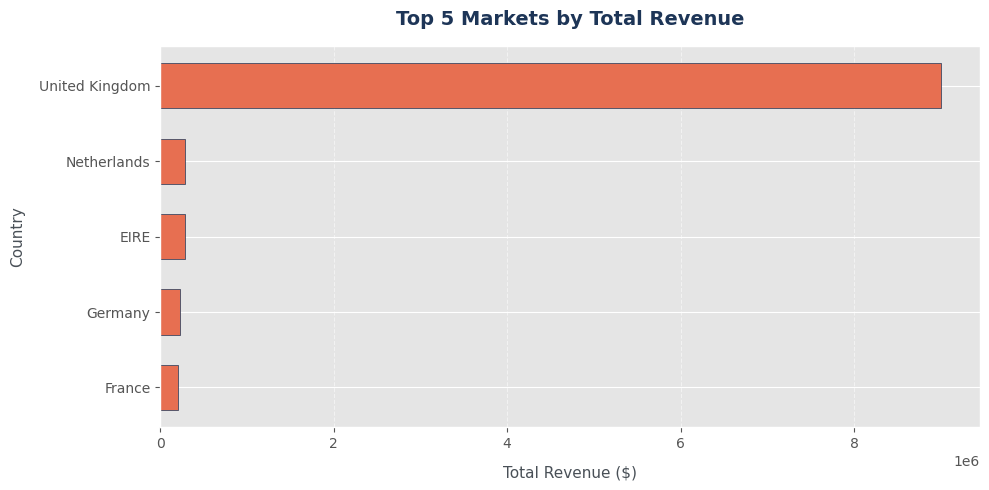

In [15]:
# 1. Calculate revenue per country and get the top 5
country_revenue = df.groupby('Country', observed=True)['TotalRevenue'].sum()
top_5_countries = country_revenue.nlargest(5).reset_index()

# 2. Plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_5_countries['Country'], top_5_countries['TotalRevenue'], color='#e76f51', edgecolor='#1d3557', height=0.6)

# 3. Clean up the design and add labels
ax.set_title('Top 5 Markets by Total Revenue', fontsize=14, fontweight='bold', pad=15, color='#1d3557')
ax.set_xlabel('Total Revenue ($)', fontsize=11, labelpad=10, color='#495057')
ax.set_ylabel('Country', fontsize=11, labelpad=10, color='#495057')
ax.invert_yaxis()  # Put the highest revenue country at the top

# Add gridlines behind the bars for easy reading
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

Sales Trends and Seasonality

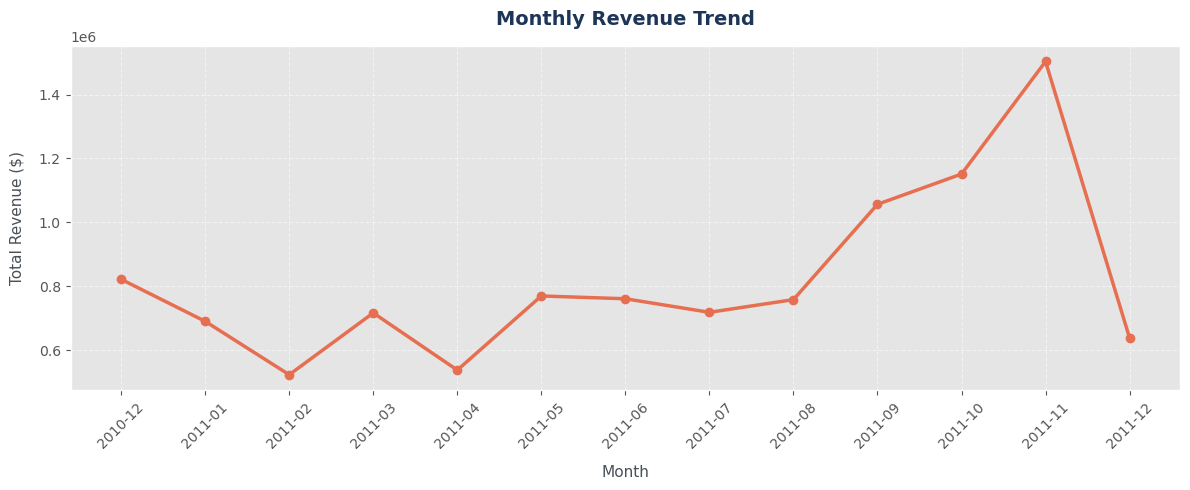

In [16]:
# 1. Create a YearMonth column for grouping
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# 2. Calculate monthly revenue (using observed=True for any categorical handling)
monthly_revenue = df.groupby('YearMonth', observed=True)['TotalRevenue'].sum().reset_index()

# 3. Convert YearMonth back to a string format just for clean plotting
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

# 4. Plot the trend line chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalRevenue'], 
        marker='o', color='#e76f51', linewidth=2.5, markersize=6)

# 5. Clean up the design and add labels
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold', pad=15, color='#1d3557')
ax.set_xlabel('Month', fontsize=11, labelpad=10, color='#495057')
ax.set_ylabel('Total Revenue ($)', fontsize=11, labelpad=10, color='#495057')

# Rotate labels slightly so they don't crowd each other
plt.xticks(rotation=45)

# Add gridlines for easy tracking of the trend line
ax.grid(axis='both', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

Product Popularity

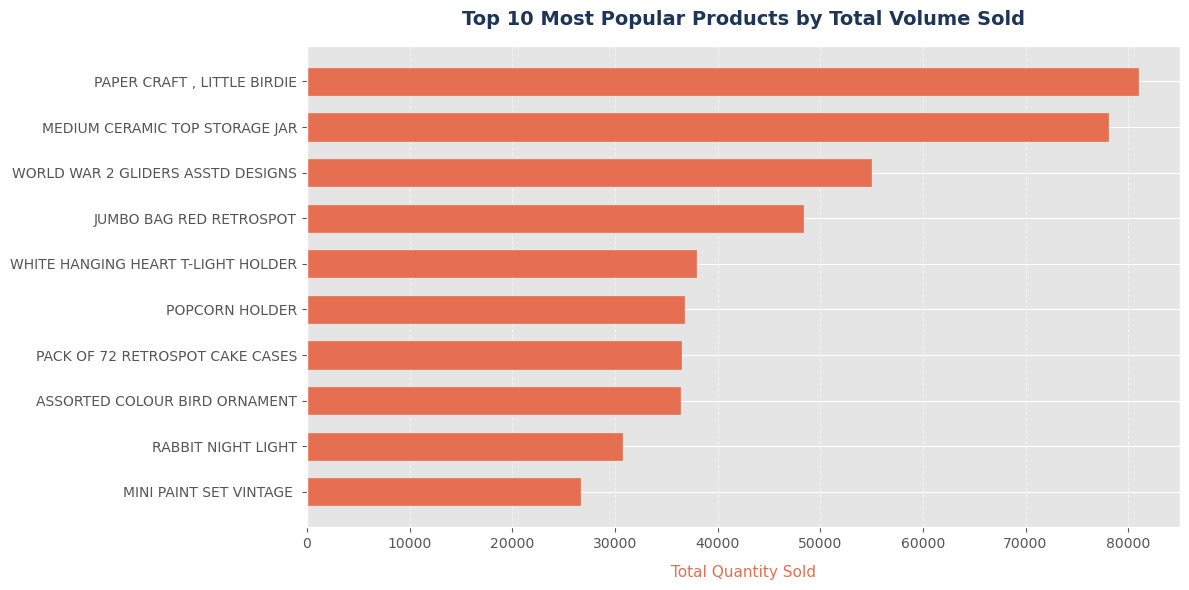

In [17]:
top_products = df.groupby('Description', observed=True)['Quantity'].sum().nlargest(10).reset_index()

fig4, ax4 = plt.subplots(figsize=(12, 6))
ax4.barh(top_products['Description'], top_products['Quantity'], color='#e76f51', edgecolor='#e76f51', height=0.6)

ax4.set_title('Top 10 Most Popular Products by Total Volume Sold', fontsize=14, fontweight='bold', pad=15, color='#1d3557')
ax4.set_xlabel('Total Quantity Sold', fontsize=11, labelpad=10, color='#e76f51')
ax4.invert_yaxis()
ax4.grid(axis='x', linestyle='--', alpha=0.5)
ax4.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [18]:
# Save the cleaned dataset to a CSV file
output_filename = "cleaned_retail_transactions.csv"
df.to_csv(output_filename, index=False)

print(f"🎉 Success! Cleaned dataset exported to: {output_filename}")
print(f"Final file shape: {df.shape}")

🎉 Success! Cleaned dataset exported to: cleaned_retail_transactions.csv
Final file shape: (524878, 10)


## Executive Summary & Data Insights

### 1. Project Overview
This portfolio project successfully engineered an end-to-end data preprocessing, cleaning, and exploratory data analysis (EDA) pipeline for a high-volume global retail dataset consisting of over 500,000 active records. The primary objective was to neutralize significant data anomalies (such as systemic bookkeeping adjustments, missing customer data, and order cancellations) to establish a single, trusted source of truth for business intelligence operations.

Following data remediation, macro business KPIs, market distributions, temporal trends, and product velocity profiles were extracted to uncover core drivers of business revenue and operational demand.
---

### Key Analytical Insights & Strategic Recommendations

#### 📊 Extreme Geographic Concentration (Market Risk)
The spatial analysis reveals that the **United Kingdom heavily dominates** the macro revenue profile of this e-commerce business. While international trade routes—specifically top export countries like Germany, France, and EIRE—demonstrate consistent traction, the business carries an aggressive single-market dependency.
* **Strategic Action:** Management should actively diversify marketing allocation toward the top 3 international export markets to cushion the business against localized economic shifts or supply chain disruptions within the UK.

#### 📈 Explicit Retail Seasonality (Supply Chain Demand)
Chronological trend analysis identifies a definitive seasonal pattern, characterized by a massive, steep acceleration in revenue starting in late Q3 and **peaking aggressively throughout Q4**. This structural spike is entirely reflective of holiday shopping behavior (e.g., Black Friday and winter holidays).
* **Strategic Action:** Fulfillment operations, warehouse staging, and staffing levels must scale up significantly ahead of time (ideally by late August). Failing to prepare inventory thresholds for this Q4 surge risks catastrophic stockouts and lost revenue.

#### 📦 Product Velocity & Demand Profiling
Analyzing product popularity shows that consumer demand is highly concentrated among a select group of top-performing items. These high-velocity assets move significantly faster than the rest of the product catalog.
* **Strategic Action:** Inventory managers should implement strict safety-stock thresholds specifically for these top 10 products. Because they drive consistent transaction volume, keeping them continuously stocked is vital to maintaining operational momentum during peak periods.